# Imports

In [2]:
import numpy as np
import csv
import matplotlib.pyplot as plt
# set rng
rng = np.random.default_rng(42)

In [3]:
incomes = []
with open('Income-Data.csv', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        incomes.append(int(row['income-range']))

print(f'Sanity check, number of incomes: {len(incomes)}\n')
print(incomes)
print(np.sort(np.unique(incomes)))

Sanity check, number of incomes: 11

[80000, 45000, 50000, 60000, 70000, 45000, 40000, 100000, 30000, 90000, 50000]
[ 30000  40000  45000  50000  60000  70000  80000  90000 100000]


In [4]:
# try all thresholds
thresholds = [20000, 30000, 40000, 45000, 50000, 60000, 70000, 80000, 90000, 100000]
sensitivity = 1
epsilons = [0.1, 0.5, 1.0, 5.0]

people_above_thresholds = {}
for X in thresholds:
    count = sum(1 for x in incomes if x > X)
    people_above_thresholds[X] = count
print(f'People above thresholds: {people_above_thresholds}')
# makes sense since 45k and 50k are duplicated

People above thresholds: {20000: 11, 30000: 10, 40000: 9, 45000: 7, 50000: 5, 60000: 4, 70000: 3, 80000: 2, 90000: 1, 100000: 0}


In [7]:
results = {}
n_repeats = 1000

for X in thresholds:
    count = people_above_thresholds[X]
    rng = np.random.default_rng(42)
    for eps in epsilons:
        b = sensitivity / eps
        noise = rng.laplace(0, b, size=n_repeats)
        noisy_counts = count + noise
        if eps not in results:
            results[eps] = {}
        results[eps][X] = []
        results[eps][X].append(noisy_counts)

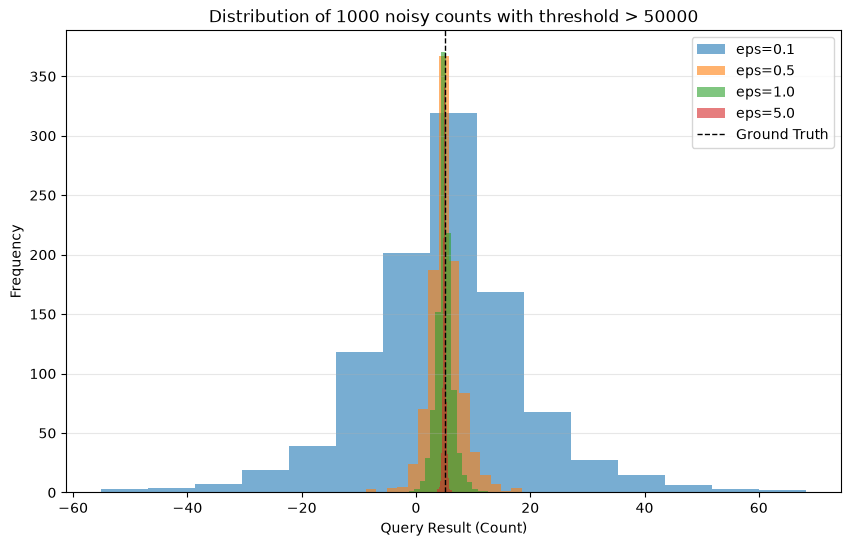

In [8]:
threshold_to_plot = 50000
plt.figure(figsize=(10, 6))

for eps in epsilons:
    plt.hist(results[eps][threshold_to_plot], bins=15, alpha=0.6, label=f'eps={eps}')

# Show ground truth
plt.axvline(people_above_thresholds[threshold_to_plot], color='black', linestyle='dashed', linewidth=1, label='Ground Truth')

plt.title(f'Distribution of {n_repeats} noisy counts with threshold > {threshold_to_plot}')
plt.xlabel('Query Result (Count)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()